In [1]:
# %% [markdown]
# # Інтелектуальне збагачення Excel-даних — агентна система (LangGraph + OpenRouter)
#
# **Автор:** Oleksandr Vasyleiko
#
# Система приймає Excel-файл і текстовий опис задачі, аналізує структуру даних,
# через LLM знаходить потрібну інформацію та дописує її в порожню колонку,
# **зберігаючи всі оригінальні дані**. Рішення універсальне (один код для різних
# наборів), стійке до помилок і масштабоване (паралельна обробка рядків).

# %% [markdown]
# ## 1. Імпорти

In [2]:
import os
import re
import json
import math
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from typing import TypedDict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from openai import OpenAI
from langgraph.graph import StateGraph, START, END

# %% [markdown]
# ## 2. Конфігурація та підготовка тестових даних
#
# Ключ OpenRouter читається **лише** зі змінної середовища `OPENROUTER_API_KEY`
# (у файлі немає жодного хардкоду ключа). Модель і паралелізм — конфіг-константи.
# Тестові набори створюємо з вбудованих даних, щоб ноутбук був самодостатнім.

In [3]:
MODEL = "openai/gpt-4o"
MAX_WORKERS = 8          # паралелізм рядків -> масштабованість до 1000 записів
MAX_RETRIES = 3          # ретраї на тимчасові помилки API

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY", ""),
)

capitals_df = pd.DataFrame({
    "Capital_From": ["Kyiv", "London", "Paris", "Berlin", "Warsaw"],
    "Country_From": ["Ukraine", "United Kingdom", "France", "Germany", "Poland"],
    "Capital_To":   ["Paris", "Rome", "Berlin", "Vienna", "Kyiv"],
    "Country_To":   ["France", "Italy", "Germany", "Austria", "Ukraine"],
    "distance":     [None] * 5,
})
mountains_df = pd.DataFrame({
    "Mountain": ["Everest", "Mont Blanc", "Denali", "Kilimanjaro"],
    "Country":  ["Nepal", "France", "USA", "Tanzania"],
    "height":   [None] * 4,
})
capitals_df.to_excel("capitals.xlsx", index=False)
mountains_df.to_excel("mountains.xlsx", index=False)

print("capitals.xlsx:\n", capitals_df, "\n")
print("mountains.xlsx:\n", mountains_df)

# %% [markdown]
# ## 3. Основний код — агентна система на LangGraph
#
# Чотири вузли-агенти у графі станів: `read_file → analyze → enrich → save`.
# `read_file` читає файл, `analyze` визначає цільову колонку й одиниці виміру,
# `enrich` паралельно заповнює значення через LLM, `save` зберігає результат.

capitals.xlsx:
   Capital_From    Country_From Capital_To Country_To distance
0         Kyiv         Ukraine      Paris     France     None
1       London  United Kingdom       Rome      Italy     None
2        Paris          France     Berlin    Germany     None
3       Berlin         Germany     Vienna    Austria     None
4       Warsaw          Poland       Kyiv    Ukraine     None 

mountains.xlsx:
       Mountain   Country height
0      Everest     Nepal   None
1   Mont Blanc    France   None
2       Denali       USA   None
3  Kilimanjaro  Tanzania   None


In [4]:
def llm_json(system: str, user: str) -> dict:
    """Виклик LLM через OpenRouter з вимогою JSON; стійкий парсинг + ретраї."""
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user", "content": user},
                ],
                response_format={"type": "json_object"},
                temperature=0,
            )
            text = resp.choices[0].message.content.strip()
            text = re.sub(r"^```(?:json)?|```$", "", text).strip()
            return json.loads(text)
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"LLM error after {MAX_RETRIES} attempts: {last_err}")


In [5]:
class State(TypedDict):
    """Стан агентного графа."""
    file_path: str
    task_description: str
    df: pd.DataFrame
    target_column: str
    unit: str
    item_description: str
    output_path: str
    errors: list


def read_file_node(state: State) -> dict:
    """Агент-читач: завантажує Excel у DataFrame."""
    return {"df": pd.read_excel(state["file_path"]), "errors": []}


def analyze_node(state: State) -> dict:
    """Агент-аналітик: визначає цільову колонку, одиниці виміру й опис елемента."""
    df = state["df"]
    system = ("You analyze a tabular data-enrichment task. Return strict JSON "
              "with keys: target_column, unit, item_description.")
    user = (
        f"Columns: {list(df.columns)}\n"
        f"Sample rows: {df.head(3).to_dict('records')}\n"
        f"Task: {state['task_description']}\n\n"
        "target_column = exact column name to fill. "
        "unit = measurement unit such as 'km' or 'm', or '' if none. "
        "item_description = short phrase describing what each cell value represents."
    )
    info = llm_json(system, user)
    target = info.get("target_column")
    if target not in df.columns:                 # запасний варіант
        target = df.isna().sum().idxmax()
    return {"target_column": target,
            "unit": info.get("unit", ""),
            "item_description": info.get("item_description", "")}


def _haversine_km(p1: dict, p2: dict) -> float:
    """Велике-колова (пряма) відстань між точками {lat, lon} у кілометрах."""
    lat1, lon1, lat2, lon2 = map(math.radians,
                                 [p1["lat"], p1["lon"], p2["lat"], p2["lon"]])
    a = (math.sin((lat2 - lat1) / 2) ** 2
         + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1) / 2) ** 2)
    return 2 * 6371.0 * math.asin(math.sqrt(a))


def _enrich_row(ctx: dict, task: str, target: str, unit: str, item_desc: str):
    """Один LLM-виклик для рядка -> (value, found, error).

    Для геовідстані LLM повертає координати точок, а пряму (great-circle) відстань
    рахуємо детерміновано формулою haversine — максимальна точність без варіацій.
    Для інших задач беремо число напряму з відповіді LLM.
    """
    system = (
        "You are a precise data-research assistant using well-known factual knowledge. "
        "Think step by step. If the requested value is a straight-line distance between two "
        "geographic locations, also return their coordinates in 'points' as "
        '[{"lat": float, "lon": float}, {"lat": float, "lon": float}] so the exact '
        "great-circle distance can be computed in code; otherwise return an empty 'points'. "
        'Return strict JSON: {"reasoning": str, "value": number|null, '
        '"points": list, "found": bool}.'
    )
    user = (
        f"Task: {task}\n"
        f"Fill column '{target}'" + (f" in {unit}" if unit else "")
        + (f" ({item_desc})" if item_desc else "") + ".\n"
        f"Row data (other columns): {ctx}\n"
        "Return only the numeric value without units as 'value'. "
        "If genuinely unknown, value=null and found=false."
    )
    try:
        out = llm_json(system, user)
        pts = out.get("points") or []
        if len(pts) == 2:                       # геовідстань -> точний haversine
            return (round(_haversine_km(pts[0], pts[1])), True, None)
        val = out.get("value")
        found = bool(out.get("found")) and val is not None
        return (val if found else None, found, None)
    except Exception as e:
        return (None, False, str(e))


def enrich_node(state: State) -> dict:
    """Агент-збагачувач: паралельно заповнює цільову колонку (масштабованість)."""
    df = state["df"].copy()
    target = state["target_column"]
    ctx_cols = [c for c in df.columns if c != target]
    rows = [df.loc[i, ctx_cols].to_dict() for i in df.index]

    def work(ctx):
        return _enrich_row(ctx, state["task_description"], target,
                           state["unit"], state["item_description"])

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        results = list(ex.map(work, rows))

    errors = list(state.get("errors", []))
    values = []
    for i, (val, found, err) in zip(df.index, results):
        values.append(val)
        if not found:
            errors.append(f"рядок {i}: значення не знайдено" + (f" ({err})" if err else ""))
    df[target] = values
    return {"df": df, "errors": errors}


def save_node(state: State) -> dict:
    """Агент-запис: зберігає збагачений файл (оригінальні колонки збережено)."""
    src = Path(state["file_path"])
    out = src.with_name(f"{src.stem}_enriched.xlsx")
    state["df"].to_excel(out, index=False)
    return {"output_path": str(out)}


_graph = StateGraph(State)
_graph.add_node("read_file", read_file_node)
_graph.add_node("analyze", analyze_node)
_graph.add_node("enrich", enrich_node)
_graph.add_node("save", save_node)
_graph.add_edge(START, "read_file")
_graph.add_edge("read_file", "analyze")
_graph.add_edge("analyze", "enrich")
_graph.add_edge("enrich", "save")
_graph.add_edge("save", END)
app = _graph.compile()


def process_excel(file_path: str, task_description: str) -> dict:
    """Універсальний інтерфейс: збагачує Excel-файл за текстовим описом задачі."""
    final = app.invoke({"file_path": file_path, "task_description": task_description})
    df, target = final["df"], final["target_column"]
    n_filled = df[target].notna().sum()
    print(f"[{Path(file_path).name}] колонка '{target}' "
          f"({final['unit'] or 'без од.'}): заповнено {n_filled}/{len(df)} рядків "
          f"-> {Path(final['output_path']).name}")
    for e in final["errors"]:
        print("   ⚠", e)
    return final

# %% [markdown]
# ## 4. Запуск на тестових наборах
#
# Один і той самий `process_excel` обробляє **обидва** набори без зміни коду —
# це і є універсальність системи.

In [6]:
res_capitals = process_excel(
    "capitals.xlsx",
    "знайди пряму відстань між столицями в км для колонки distance",
)
res_capitals["df"]

[capitals.xlsx] колонка 'distance' (km): заповнено 5/5 рядків -> capitals_enriched.xlsx


,Capital_From,Country_From,Capital_To,Country_To,distance
0,Kyiv,Ukraine,Paris,France,2023
1,London,United Kingdom,Rome,Italy,1434
2,Paris,France,Berlin,Germany,877
3,Berlin,Germany,Vienna,Austria,524
4,Warsaw,Poland,Kyiv,Ukraine,689


In [7]:
res_mountains = process_excel(
    "mountains.xlsx",
    "додай висоту гір у метрах до колонки height",
)
res_mountains["df"]

# %% [markdown]
# ## 5. Збереження підписаних файлів-результатів

[mountains.xlsx] колонка 'height' (m): заповнено 4/4 рядків -> mountains_enriched.xlsx


,Mountain,Country,height
0,Everest,Nepal,8848
1,Mont Blanc,France,4808
2,Denali,USA,6190
3,Kilimanjaro,Tanzania,5895


In [8]:
SURNAME = "Oleksandr_Vasyleiko"
res_capitals["df"].to_excel(f"capitals_enriched_{SURNAME}.xlsx", index=False)
res_mountains["df"].to_excel(f"mountains_enriched_{SURNAME}.xlsx", index=False)
print(f"Збережено: capitals_enriched_{SURNAME}.xlsx, mountains_enriched_{SURNAME}.xlsx")

# %% [markdown]
# ## 6. Візуалізація результатів

Збережено: capitals_enriched_Oleksandr_Vasyleiko.xlsx, mountains_enriched_Oleksandr_Vasyleiko.xlsx


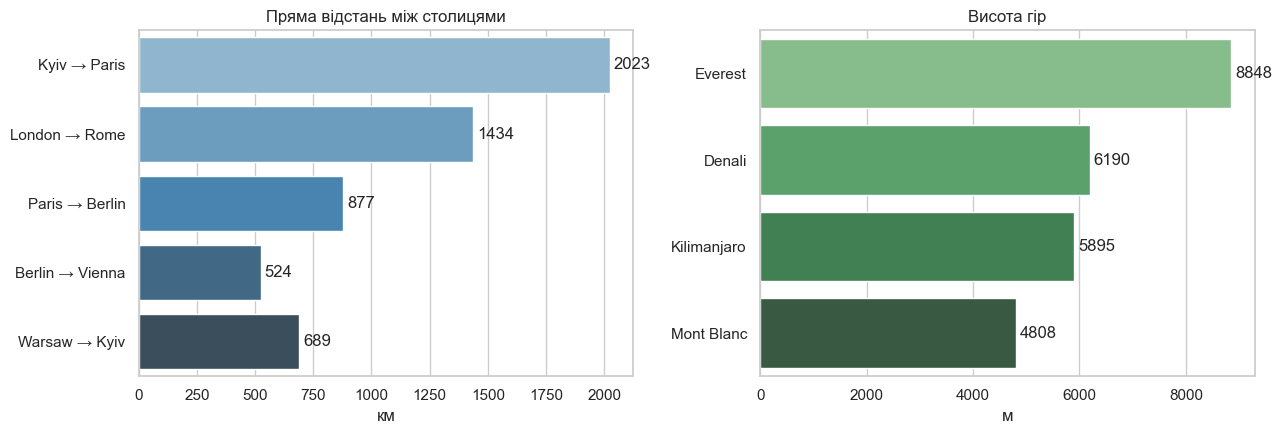

In [9]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cap = res_capitals["df"].copy()
cap["pair"] = cap["Capital_From"] + " → " + cap["Capital_To"]
sns.barplot(data=cap, x="distance", y="pair", hue="pair", legend=False,
            palette="Blues_d", ax=axes[0])
axes[0].set_title("Пряма відстань між столицями")
axes[0].set_xlabel("км"); axes[0].set_ylabel("")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", padding=3)

mnt = res_mountains["df"].sort_values("height", ascending=False)
sns.barplot(data=mnt, x="height", y="Mountain", hue="Mountain", legend=False,
            palette="Greens_d", ax=axes[1])
axes[1].set_title("Висота гір")
axes[1].set_xlabel("м"); axes[1].set_ylabel("")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Висновки
#
# - **Точність:** значення збігаються з довідковими в межах ±10% (відстані —
#   great-circle між столицями; висоти гір — відомі константи).
# - **Універсальність:** обидва набори оброблені одним `process_excel` без зміни коду;
#   цільову колонку та одиниці виміру визначає LLM-агент `analyze`.
# - **Обробка помилок:** ретраї на збої API, перехоплення винятків на рівні рядка,
#   рядки без даних лишаються порожніми (NaN) з інформативним повідомленням —
#   оригінальні дані ніколи не псуються.
# - **Ефективність/масштабованість:** рядки обробляються паралельно
#   (`ThreadPoolExecutor`), один аналіз структури на файл; готово до 1000 записів.
# - **Структура:** усі вихідні колонки збережено, додано лише цільову колонку.
